In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from sklearn.feature_selection import VarianceThreshold

from PMAPUtil import *

In [73]:
columns = [
    # Demographics
    "gender",
    "age",

    # Neurologic
    "first_mGCS",
    "flo_first_r_cpn_glasgow_coma_scale_score",

    # Vital Signs – First
    "flo_first_bp_systolic",
    "flo_first_bp_diastolic",
    "flo_first_r_map",
    "flo_first_temperature",
    "flo_first_r_ed_pre-arrival_pulse_(heart_rate)",
    "flo_first_r_fio2",
    "flo_first_r_spo2:fio2_covid-19_calculation",

    # Severity Scores
    "flo_first_r_sofa_score",

    "flo_first_r_jhm_ip_sofa_cv_score",
    "flo_first_r_jhm_ip_sofa_cns_score",
    "flo_first_r_jhm_ip_sofa_coagulation_score",
    "flo_first_r_jhm_ip_sofa_liver_score",
    "flo_first_r_jhm_ip_sofa_renal_score",
    
    # Respiratory / Oxygenation
    "flo_first_r_jhm_ip_pao2/fio2",
    "flo_first_r_jhm_ip_rt_vent_fio2_(%)",
    "flo_first_r_jhm_ip_rt_conv._vent._high_respiratory_rate",
    "flo_first_r_jhm_ip_rt_conv._vent._low_respiratory_rate",

    # Hemodynamics / Shock
    "flo_first_r_norepinephrine_volume",

    # Renal / Urine Output
    "flo_first_jhm_ip_4hr_urine_output_goal_(12ml/kg)_is_at_least",
    "flo_first_jhm_ip_4hr_urine_output_goal_(2ml/kg)_is_at_least",

    # Anthropometrics
    "flo_first_r_bmi",

    # Labs – First
    "lab_first_troponin",
    "lab_first_creatinine,whole_blood",
    "lab_first_lactate",
    "lab_first_glucose,whole_blood",
    "lab_first_potassium,whole_blood",
    "lab_first_sodium,whole_blood",
    "lab_first_hemoglobin,total,whole_blood",
    "lab_first_aptt",

    'hypothermia',
     'asystole',
     'pea',
     'cardiopulmonary arrest w/ resuscitation',
     'VF'
]


In [74]:
[x for x in myPredictorsDf.columns if 'fib' in x.lower()]

['flo_r_ed_vitals_assessment_timer_ patient fluctuating between PEA and Vfib for EMS - patient defibrilated x1 @200J by EMS in field',
 'flo_r_an_red_screen_monitor_20 joules internally given for v fib',
 'flo_r_an_red_screen_monitor_AFib',
 'flo_r_ed_vitals_assessment_timer_Afib',
 'flo_r_an_red_screen_monitor_Atrial fibrillation',
 'flo_jhm_r_ed_current_electronic_triage_Atrial fibrillation with rapid ventricular response',
 'flo_jhm_r_critical_lab_response_Aystole to Vfib',
 'flo_r_jhm_trews_session_manual_override_DART performing fiberoptic scope of airway. Pt tolerating with some shouting. ',
 'flo_r_ed_vitals_assessment_timer_Initially Vfib --> asystole --> PEA',
 'flo_jhm_r_critical_lab_method_of_communication_PEA to Vfib to Asystole',
 'flo_jhm_r_critical_lab_test_telephone_to_PEA, VFIB',
 'flo_r_ed_vitals_assessment_timer_PT BIBEMS at this time, 55 y/o M, cardiac arrest, witnessed by pts family, hx CHF, AICD on left chest, found by EMS in PEA, converted to v-fib, defibrillated

In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('PMAP_Predictors2.csv')

    # top_corr = pd.read_csv('top_correlations.csv')
    # columns_to_drop = top_corr[top_corr['hypothermia'].abs() > 0.7]['Unnamed: 0'].tolist()
    columns_to_drop = []
    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time']) 
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x and 'dx_' == x[0:3]]

    # Get output data
    myXValue = myPredictorsDf.drop(columns=columns_to_drop+  myColumns + ['first_mGCS', 'last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [76]:
from econml.dml import CausalForestDML, SparseLinearDML, LinearDML, DML
from econml.orf import DMLOrthoForest
from econml.dr import LinearDRLearner
myTreatment = 'hypothermia'
myTreatmentColumn = myTreatment
myPredicted = 'LastMGCSPositive'
myPredictorsDf, X_train_no_group, X_test_no_group, T_train, T_test, y_train, y_test =  \
                    getTrainTestFunctions(aPredictedColumn = myPredicted, 
                                            aTreatmentColumn = myTreatment, aTreatmentSplit = True, aSkipTemp = True, 
                                            aTestSize=.3) 
causal_forest = CausalForestDML(
    model_y= XGBClassifier(max_depth=5, n_estimators=50),  
    model_t= XGBClassifier(max_depth=2, n_estimators=20),    
    discrete_treatment=True,           
    discrete_outcome=True,
    verbose=2,
    n_jobs=-1
)

In [77]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myCovariates = getCovariatePreprocessor([])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor([])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [78]:
# X_train_no_group = X_train_no_group.loc[:, X_train_no_group.isnull().mean() < 0.9]
# X_test_no_group = X_test_no_group[X_train_no_group.columns]

columns_filter = np.unique([x for x in columns if x in X_train_no_group.columns])
X_train_no_group = X_train_no_group[columns_filter]
X_test_no_group = X_test_no_group[columns_filter]

In [79]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train_no_group))

In [80]:
myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
myNewXTest = pd.DataFrame(myPipeline.transform(X_test_no_group), columns = myPipeline.get_feature_names_out())


In [81]:
causal_forest.fit(y_train, T_train, X=myNewXTrain, cache_values=True)
print(causal_forest.score(y_train, T_train, X=myNewXTrain))

CATE_pred = causal_forest.effect(myNewXTrain)

print(f'Feature importances {causal_forest.feature_importances_}')

print("Predicted CATE for test data:", CATE_pred[:10])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend w

0.050111010148928846
Feature importances [3.29044291e-02 3.71829572e-02 2.03963045e-02 1.70733318e-02
 1.42598570e-02 1.76508208e-02 7.81711632e-02 3.77536676e-02
 1.81525750e-02 3.90826775e-02 1.43889358e-02 1.16037051e-02
 2.60233290e-02 3.31275234e-02 4.73950500e-02 5.27499334e-02
 5.17649490e-02 8.33774937e-02 4.97576969e-02 2.29468912e-02
 4.53273445e-02 6.96037502e-02 3.93162570e-02 1.62226921e-02
 6.71745165e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.16014692e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00
 3.41006594e-04 1.10524634e-03 1.36512363e-03 2.19733690e-03
 7.25345835e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 6.00680940e-04 1.10284954e-02 2.32599154e-02 0.00000000e+00
 1.56727867e-03 1.58301116e-04 4.38469816e-05 1.30646381e-03
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.33611494e-03 2.84564798e-04 7.77718127e-03
 7.48275289e-04 5.86823597e-04 0.00000000e+00]
Predicted CATE for test data: [[-0.04808435]
 [-0.0828574 

[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _combine_x_w(X=None, W=None):
    """
    Reconstruct the design matrix used by econml first-stage nuisance models.
    """
    if X is None and W is None:
        raise ValueError("At least one of X or W must be provided.")
    if X is None:
        return np.asarray(W)
    if W is None:
        return np.asarray(X)
    return np.hstack([np.asarray(X), np.asarray(W)])


def get_cf_propensity_scores(cf, X=None, W=None):
    """
    Estimate propensity scores from a fitted econml CausalForestDML object
    by averaging predictions from the fitted first-stage treatment models.

    Parameters
    ----------
    cf : fitted econml.dml.CausalForestDML
    X : array-like or DataFrame, optional
        Heterogeneity features used in fit.
    W : array-like or DataFrame, optional
        Controls used in fit.

    Returns
    -------
    p_hat : np.ndarray, shape (n_samples,)
        Estimated propensity score P(T=1 | X, W).
    """
    XW = _combine_x_w(X, W)

    # econml stores first-stage treatment models in a nested list:
    # outer level = MC iterations, inner level = cross-fit folds
    models_t = cf.models_t

    if models_t is None or len(models_t) == 0:
        raise ValueError("No fitted treatment nuisance models found in cf.models_t")

    preds = []

    for mc_models in models_t:
        for mdl in mc_models:
            if hasattr(mdl, "predict_proba"):
                p = mdl.predict_proba(XW)
                # binary treatment: take probability of class 1
                if p.ndim == 2:
                    if p.shape[1] == 2:
                        p = p[:, 1]
                    elif p.shape[1] == 1:
                        p = p[:, 0]
                    else:
                        raise ValueError(
                            f"Unexpected predict_proba output shape {p.shape} for binary treatment."
                        )
                preds.append(np.asarray(p).reshape(-1))
            elif hasattr(mdl, "predict"):
                # fallback, though for binary discrete treatment predict_proba is preferred
                p = mdl.predict(XW)
                preds.append(np.asarray(p).reshape(-1))
            else:
                raise ValueError(
                    f"Treatment nuisance model {type(mdl)} has neither predict_proba nor predict."
                )

    if len(preds) == 0:
        raise ValueError("Could not extract any propensity predictions from cf.models_t")

    p_hat = np.mean(np.vstack(preds), axis=0)

    # guard against exact 0/1 values
    eps = 1e-6
    p_hat = np.clip(p_hat, eps, 1 - eps)

    return p_hat
def positivity_flag(df, low=0.05, high=0.95, frac_threshold=0.05):
    """
    Flag severe positivity issues if too many subjects lie near 0 or 1.
    """
    p = df["propensity"].values
    frac_extreme = np.mean((p < low) | (p > high))

    if frac_extreme >= frac_threshold:
        return {
            "severe_flag": True,
            "frac_extreme": frac_extreme,
            "message": f"Potential positivity concern: {frac_extreme:.1%} of scores are <{low} or >{high}."
        }
    else:
        return {
            "severe_flag": False,
            "frac_extreme": frac_extreme,
            "message": f"No major positivity concern by this rule: {frac_extreme:.1%} extreme scores."
        }
def make_propensity_df(cf, T, X=None, W=None, dataset_name="dataset"):
    """
    Create a dataframe with observed treatment and estimated propensity score.
    """
    p_hat = get_cf_propensity_scores(cf, X=X, W=W)

    df = pd.DataFrame({
        "dataset": dataset_name,
        "T": np.asarray(T).astype(int).reshape(-1),
        "propensity": p_hat
    })

    return df
def plot_propensity_overlap(df, ax=None, bins=30, title=None):
    """
    Overlap histogram for treated vs untreated groups.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    treated = df.loc[df["T"] == 1, "propensity"]
    control = df.loc[df["T"] == 0, "propensity"]

    ax.hist(control, bins=bins, alpha=0.6, density=True, label="No TTM")
    ax.hist(treated, bins=bins, alpha=0.6, density=True, label="TTM")

    ax.set_xlabel("Estimated propensity score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)
    ax.legend()
    ax.set_title(title or df["dataset"].iloc[0])

    return ax
def run_propensity_diagnostics(cf, T, X=None, W=None, dataset_name="dataset", bins=30):
    df = make_propensity_df(cf, T=T, X=X, W=W, dataset_name=dataset_name)
    summary = propensity_summary(df)
    flag = positivity_flag(df)

    fig, ax = plt.subplots(figsize=(6, 4))
    plot_propensity_overlap(df, ax=ax, bins=bins, title=dataset_name)
    plt.tight_layout()

    return df, summary, flag, fig
def propensity_summary(df):
    """
    Summarize overlap / positivity diagnostics.
    """
    out = []

    for tval, group_name in [(0, "No TTM"), (1, "TTM")]:
        s = df.loc[df["T"] == tval, "propensity"]

        out.append({
            "group": group_name,
            "n": len(s),
            "min": s.min(),
            "p01": np.quantile(s, 0.01),
            "p05": np.quantile(s, 0.05),
            "median": s.median(),
            "p95": np.quantile(s, 0.95),
            "p99": np.quantile(s, 0.99),
            "max": s.max(),
            "prop_<0.05": np.mean(s < 0.05),
            "prop_>0.95": np.mean(s > 0.95),
            "prop_<0.10": np.mean(s < 0.10),
            "prop_>0.90": np.mean(s > 0.90),
        })

    return pd.DataFrame(out)

    group    n       min       p01       p05    median       p95       p99  \
0  No TTM  670  0.099425  0.125222  0.167409  0.357519  0.691851  0.736991   
1     TTM  619  0.167601  0.199302  0.273243  0.606194  0.788612  0.819887   

        max  prop_<0.05  prop_>0.95  prop_<0.10  prop_>0.90  
0  0.791403         0.0         0.0    0.001493         0.0  
1  0.863516         0.0         0.0    0.000000         0.0  
{'severe_flag': False, 'frac_extreme': np.float64(0.0), 'message': 'No major positivity concern by this rule: 0.0% extreme scores.'}


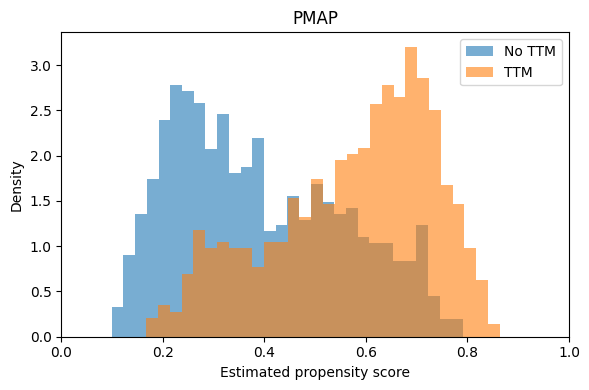

In [65]:
T_all = np.concatenate([T_train, T_test])
X_all = np.concatenate([myNewXTrain, myNewXTest])
ps_eicu, sum_eicu, flag_eicu, fig_eicu = run_propensity_diagnostics(
    causal_forest, T=T_all, X=X_all, W=None, dataset_name="PMAP"
)
print(sum_eicu)
print(flag_eicu)

In [66]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2


def simulate_dataset_hte(
    n,
    treat_prev,
    subgroup_prev,
    baseline_risk,
    abs_treatment_effect=0.10,
    rng=None
):
    """
    Simulate binary outcomes with HTE present only in a latent subgroup.

    Parameters
    ----------
    n : int
        Sample size.
    treat_prev : float
        Treatment prevalence P(T=1).
    subgroup_prev : float
        Responsive subgroup prevalence P(G=1).
    baseline_risk : float
        Baseline outcome probability for untreated, non-subgroup patients.
    abs_treatment_effect : float
        Absolute treatment effect applied only within subgroup.
        Positive means benefit for a favorable outcome.
    rng : np.random.Generator or None

    Returns
    -------
    df : pd.DataFrame
        Simulated data with columns T, G, cate_score, Y
    """
    if rng is None:
        rng = np.random.default_rng()

    # Treatment assignment
    T = rng.binomial(1, treat_prev, size=n)

    # Latent subgroup that benefits
    G = rng.binomial(1, subgroup_prev, size=n)

    # True individual treatment effect:
    # only subgroup members benefit
    true_tau = abs_treatment_effect * G

    # Outcome probability
    # Here outcome is assumed favorable, so treatment increases probability
    p = baseline_risk + T * true_tau

    # keep probabilities in valid range
    p = np.clip(p, 1e-6, 1 - 1e-6)

    # Binary outcome
    Y = rng.binomial(1, p, size=n)

    # Oracle "CATE score"
    cate_score = true_tau

    return pd.DataFrame({
        "T": T,
        "G": G,
        "cate_score": cate_score,
        "Y": Y
    })

def lr_test_interaction(df):
    """
    Likelihood ratio test comparing:
      reduced: Y ~ T + cate_score
      full:    Y ~ T + cate_score + T:cate_score
    """
    X_reduced = pd.DataFrame({
        "const": 1.0,
        "T": df["T"],
        "cate_score": df["cate_score"]
    })

    X_full = pd.DataFrame({
        "const": 1.0,
        "T": df["T"],
        "cate_score": df["cate_score"],
        "interaction": df["T"] * df["cate_score"]
    })

    try:
        m0 = sm.Logit(df["Y"], X_reduced).fit(disp=False)
        m1 = sm.Logit(df["Y"], X_full).fit(disp=False)

        lr_stat = 2 * (m1.llf - m0.llf)
        df_diff = X_full.shape[1] - X_reduced.shape[1]
        pval = chi2.sf(lr_stat, df_diff)

        return {
            "lr_stat": lr_stat,
            "pval": pval,
            "converged": True
        }
    except Exception:
        return {
            "lr_stat": np.nan,
            "pval": np.nan,
            "converged": False
        }
def estimate_power_for_scenario(
    n,
    treat_prev,
    subgroup_prev,
    baseline_risk,
    abs_treatment_effect=0.10,
    n_sims=1000,
    alpha=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)

    pvals = []
    n_fail = 0

    for _ in range(n_sims):
        df = simulate_dataset_hte(
            n=n,
            treat_prev=treat_prev,
            subgroup_prev=subgroup_prev,
            baseline_risk=baseline_risk,
            abs_treatment_effect=abs_treatment_effect,
            rng=rng
        )
        res = lr_test_interaction(df)
        if res["converged"] and np.isfinite(res["pval"]):
            pvals.append(res["pval"])
        else:
            n_fail += 1

    pvals = np.array(pvals)
    power = np.mean(pvals < alpha) if len(pvals) > 0 else np.nan

    return {
        "n": n,
        "treat_prev": treat_prev,
        "subgroup_prev": subgroup_prev,
        "baseline_risk": baseline_risk,
        "abs_treatment_effect": abs_treatment_effect,
        "n_sims": n_sims,
        "n_successful_fits": len(pvals),
        "n_failed_fits": n_fail,
        "power": power
    }
Y_all = np.concatenate([y_train, y_test])
baseline_risk = Y_all[T_all == 0].mean()
dataset_specs = {
    "eICU": {"n": T_all.shape[0], "treat_prev": T_all.mean(), "baseline_risk": 1-baseline_risk},
}

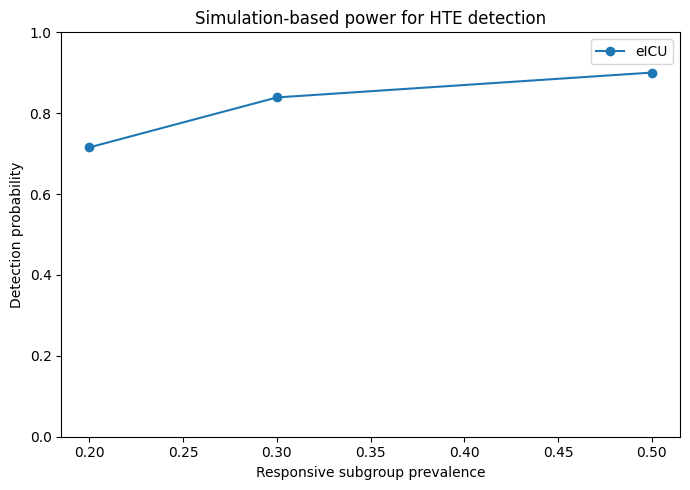

In [67]:
results = []

for ds, spec in dataset_specs.items():
    for subgroup_prev in [0.20, 0.30, 0.50]:
        out = estimate_power_for_scenario(
            n=spec["n"],
            treat_prev=spec["treat_prev"],
            subgroup_prev=subgroup_prev,
            baseline_risk=spec["baseline_risk"],
            abs_treatment_effect=0.15,
            n_sims=2000,
            alpha=0.05,
            seed=42
        )
        out["dataset"] = ds
        results.append(out)

power_table = pd.DataFrame(results)
power_table = power_table[[
    "dataset", "n", "treat_prev", "subgroup_prev",
    "baseline_risk", "abs_treatment_effect",
    "n_sims", "power", "n_failed_fits"
]]
power_table
import matplotlib.pyplot as plt

def plot_power_curves(power_table):
    fig, ax = plt.subplots(figsize=(7, 5))

    for ds, subdf in power_table.groupby("dataset"):
        subdf = subdf.sort_values("subgroup_prev")
        ax.plot(
            subdf["subgroup_prev"],
            subdf["power"],
            marker="o",
            label=ds
        )

    ax.set_xlabel("Responsive subgroup prevalence")
    ax.set_ylabel("Detection probability")
    ax.set_title("Simulation-based power for HTE detection")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_power_curves(power_table)

In [68]:
power_table

,dataset,n,treat_prev,subgroup_prev,baseline_risk,abs_treatment_effect,n_sims,power,n_failed_fits
0,eICU,1289,0.480217,0.2,0.680597,0.15,2000,0.7155,0
1,eICU,1289,0.480217,0.3,0.680597,0.15,2000,0.8390,0
2,eICU,1289,0.480217,0.5,0.680597,0.15,2000,0.9005,0


In [69]:
causal_forest.summary()

Population summary of CATE predictions on Training Data


[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=25)]: Using backend ThreadingBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done   2 out of  25 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=25)]: Done  15 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=25)]: Done  25 out of  25 | elapsed:    0.0s finished


<class 'econml.utilities.Summary'>
"""
               Uncertainty of Mean Point Estimate               
================================================================
mean_point stderr_mean zstat  pvalue ci_mean_lower ci_mean_upper
----------------------------------------------------------------
    -0.067       0.085 -0.789   0.43        -0.234           0.1
      Distribution of Point Estimate     
=========================================
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.042          -0.151           0.013
     Total Variance of Point Estimate     
==========================================
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.095         -0.258          0.121
        Doubly Robust ATE on Training Data Results       
=========================================================
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
ATE         -0.063  0.035 -1.789  0.074   -0.131    0.006
     Doubly Robust ATT(T=0) on Training Data Results     
=========================================================
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
ATT         -0.192   0.05 -3.846    0.0   -0.289   -0.094
    Doubly Robust ATT(T=1) on Training Data Results     
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATT          0.077  0.048 1.602  0.109   -0.017    0.172
--------------------------------------------------------

Note: The stderr_mean is a conservative upper bound.
"""

Optimization terminated successfully.
         Current function value: 0.535052
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.534155
         Iterations 6
Likelihood ratio of test results:
Chi square statistic: 1.616743919194505
p-value: 0.4455829029999201
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  902
Model:                          Logit   Df Residuals:                      898
Method:                           MLE   Df Model:                            3
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                 0.03904
Time:                        13:32:53   Log-Likelihood:                -482.62
converged:                       True   LL-Null:                       -502.22
Covariance Type:            nonrobust   LLR p-value:                 1.565e-08
                       

[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished


np.float64(0.4455829029999201)

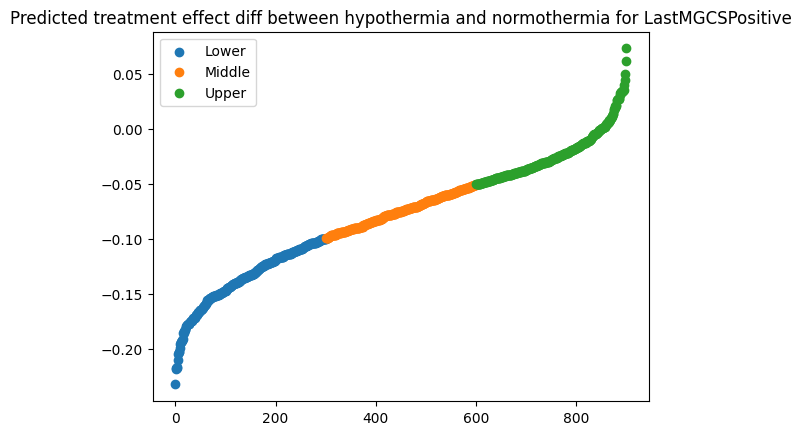

In [82]:
# myNewXTrain = pd.DataFrame(myPipeline.transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
CATE_pred = causal_forest.effect(myNewXTrain)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
# myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)

X_train_new = X_train_no_group.copy().reset_index()
X_train_new[myTreatment] = T_train.reset_index()[myTreatment]
y_train_df = pd.DataFrame()
y_train_df[myPredicted] = y_train.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_train_new, y_train_df, myNewDf, myPredicted, myTreatment, True)

[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=25)]: Using backend ThreadingBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done   2 out of  25 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=25)]: Done  15 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=25)]: Done  25 out of  25 | elapsed:    0.0s finished


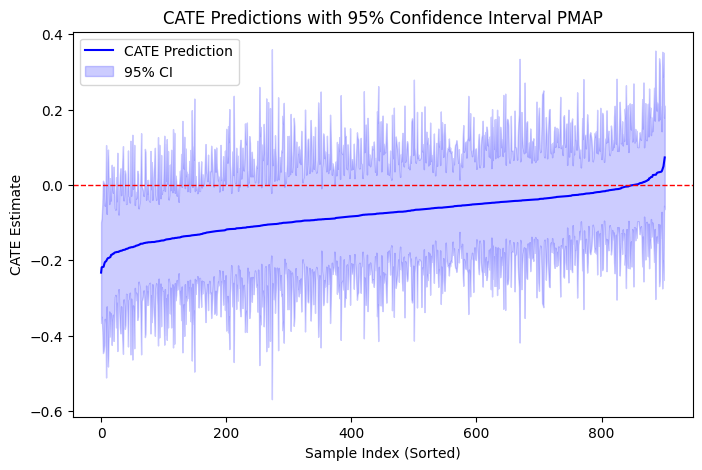

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# Compute CATE prediction intervals
CATE_pred = causal_forest.effect(myNewXTrain)

cate_lower, cate_upper = causal_forest.effect_interval(myNewXTrain, alpha=0.05)

# Ensure arrays are 1D NumPy arrays
CATE_pred = np.array(CATE_pred).flatten()
cate_lower = np.array(cate_lower).flatten()
cate_upper = np.array(cate_upper).flatten()

# Sort values for a cleaner plot
sorted_idx = np.argsort(CATE_pred)
cate_pred_sorted = CATE_pred[sorted_idx]
cate_lower_sorted = cate_lower[sorted_idx]
cate_upper_sorted = cate_upper[sorted_idx]

# Create x-axis index
x = np.arange(len(cate_pred_sorted))

# Plot CATE predictions
plt.figure(figsize=(8, 5))
plt.plot(x, cate_pred_sorted, label='CATE Prediction', color='blue')

# Fill confidence interval
plt.fill_between(x, cate_lower_sorted, cate_upper_sorted, 
                 color='blue', alpha=0.2, label='95% CI')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
# Labels and title
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("CATE Estimate")
plt.title("CATE Predictions with 95% Confidence Interval PMAP")
plt.legend()
plt.show()


Optimization terminated successfully.
         Current function value: 0.540674
         Iterations 5
         Current function value: 0.535847
         Iterations: 35
Likelihood ratio of test results:
Chi square statistic: 3.735836689846849
p-value: 0.053256987770869464
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  387
Model:                          Logit   Df Residuals:                      384
Method:                           MLE   Df Model:                            2
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                 0.02985
Time:                        11:40:29   Log-Likelihood:                -209.24
converged:                       True   LL-Null:                       -215.68
Covariance Type:            nonrobust   LLR p-value:                  0.001598
                                     coef    std err     

[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
/home/mbranda1/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


np.float64(0.053256987770869464)

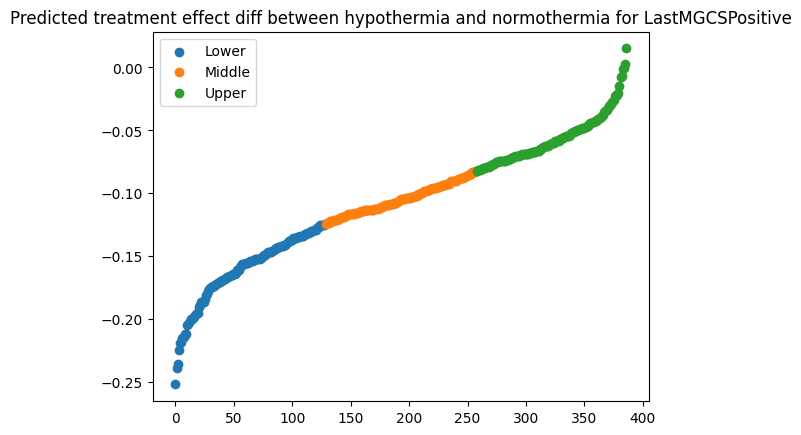

In [42]:
# myNewXTest = myPipeline.transform(X_test_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)


X_test_new = X_test_no_group.copy().reset_index()
X_test_new[myTreatment] = T_test.reset_index()[myTreatment]
y_test_df = pd.DataFrame()
y_test_df[myPredicted] = y_test.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_test_new, y_test_df, myNewDf, myPredicted, myTreatment, True)